# IMPROVE High-Fabs Comparison

This notebook tests the April 14 decision fork from the Addis/SPARTAN HIPS discussion: do IMPROVE samples in the same high-absorption regime as ETAD/Addis show the same kind of compressed `fAbs` versus EC relationship, or does the issue look SPARTAN/Addis-specific?

The analysis is anchored to the April 2026 FTIR-group deck narrative:

- Addis is uniquely anomalous across HIPS vs aethalometer and HIPS vs FTIR-EC.
- Iron, dust, seasonality, blanks, and simple volume correction are negative tests.
- The remaining mechanism is an extreme HIPS/filter-loading regime.
- The deciding comparison is IMPROVE high-`fAbs` behavior at similar optical/filter-loading conditions.

Inputs:

- FED IMPROVE aerosol exports in `Data/Improve`, including Excel workbooks from the Query Wizard and older delimited/zip exports if present.
- Local SPARTAN unified filter data for ETAD reference ranges and filter-loading context.


In [1]:
from pathlib import Path
import io
import re
import zipfile

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

PROJECT_DIR = Path('/Users/ahmadjalil/github/aethmodular')
WORK_DIR = PROJECT_DIR / 'research' / 'ftir_hips_chem'
IMPROVE_DIR = Path('/Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Improve')
SPARTAN_FILTER_PATH = WORK_DIR / 'Filter Data' / 'unified_filter_dataset.pkl'
OUT_DIR = WORK_DIR / 'output' / 'improve_high_fabs_comparison'
OUT_DIR.mkdir(parents=True, exist_ok=True)

HIGH_TAIL_THRESHOLD = 70.0
BOOTSTRAP_N = 1000
BOOTSTRAP_MAX_ROWS = 30_000
RANDOM_SEED = 42

# IMPROVE area handling is a sensitivity until the exact applicable collection area is confirmed per sample/site.
# FED Dataset History says Module A deposit area increased from 2.2 to 3.5 cm2 starting 1995, phased in by site.
# The Version II SOP also lists 2.2 and 4.0 cm2 cassette collection areas, so 4.0 is retained as a sensitivity only.
PRIMARY_IMPROVE_AREA_CM2 = 3.5
IMPROVE_AREA_SENSITIVITY_CM2 = [2.2, 3.5, 4.0]
SPARTAN_AREA_REFERENCE_CM2 = 3.53

print(f'IMPROVE directory: {IMPROVE_DIR}')
print(f'SPARTAN filter dataset: {SPARTAN_FILTER_PATH}')
print(f'Output directory: {OUT_DIR}')


IMPROVE directory: /Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Improve
SPARTAN filter dataset: /Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/Filter Data/unified_filter_dataset.pkl
Output directory: /Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/improve_high_fabs_comparison


## Helpers

The loader handles both current FED Excel workbooks and older public delimited/zip exports. For FED text exports it finds the `Data` section, then reads the table after the header. All `-999` sentinel values are treated as missing.

The Excel workbooks also carry useful metadata sheets (`Sites`, `Dataset History`, `Status Flags`, `Provider Flags`, and parameter dictionaries), which are exported alongside the analysis outputs for auditability.


In [2]:
NA_VALUES = ['-999', -999, '-999.0', -999.0]
CHEMISTRY_COLS = [
    'Dataset', 'SiteCode', 'POC', 'Date', 'AuxID',
    'ECf_Val', 'OCf_Val', 'fAbs_Val', 'FlowRate_Val',
    'FEf_Val', 'MF_Val', 'SampDur_Val', 'SOILf_Val',
]
RT_REQUIRED = {'SiteCode', 'Date', 'RefF_635_Val', 'TransF_635_Val'}
METADATA_SHEETS = ['Datasets', 'Overview', 'Sites', 'Parameters', 'Site History', 'Dataset History', 'Status Flags', 'Provider Flags']


def safe_area(area):
    return str(area).replace('.', 'p')


def _read_text_file(path: Path) -> str:
    return path.read_text(errors='replace')


def _iter_text_sources(directory: Path):
    patterns = ['*.txt', '*.TXT', '*.csv', '*.CSV', '*.psv', '*.PSV', '*.zip', '*.ZIP']
    seen = set()
    for pattern in patterns:
        for path in sorted(directory.glob(pattern)):
            if path in seen:
                continue
            seen.add(path)
            if path.suffix.lower() == '.zip':
                with zipfile.ZipFile(path) as zf:
                    for member in zf.namelist():
                        if member.endswith('/'):
                            continue
                        if not member.lower().endswith(('.txt', '.csv', '.psv')):
                            continue
                        data = zf.read(member).decode('utf-8', errors='replace')
                        yield f'{path}::{member}', data
            else:
                yield str(path), _read_text_file(path)


def _find_fed_data_header(lines):
    """Return the header line index for a FED multi-section export."""
    for i, line in enumerate(lines):
        if line.strip() == 'Data':
            for j in range(i + 1, min(i + 20, len(lines))):
                if lines[j].lstrip().startswith('Dataset') and 'SiteCode' in lines[j]:
                    return j
    for i, line in enumerate(lines):
        if line.lstrip().startswith('Dataset') and 'SiteCode' in line:
            return i
    return None


def _parse_table_from_text(source_name: str, text: str):
    lines = text.splitlines()
    header_idx = _find_fed_data_header(lines)

    if header_idx is not None:
        header = lines[header_idx].strip()
        cols = header.split('|') if '|' in header else header.split()
        data_text = '\n'.join(lines[header_idx + 1:])
        sep = '|' if '|' in header else r'\s+'
        df = pd.read_csv(
            io.StringIO(data_text),
            sep=sep,
            names=cols,
            engine='python',
            na_values=NA_VALUES,
            keep_default_na=True,
        )
        return df, {'source': source_name, 'format': 'fed_multisection', 'header_line': header_idx + 1, 'columns': cols}

    nonempty = [line for line in lines if line.strip()]
    if not nonempty:
        return pd.DataFrame(), {'source': source_name, 'format': 'empty', 'header_line': None, 'columns': []}
    first = nonempty[0]
    sep = '|' if '|' in first else r'\s+'
    df = pd.read_csv(
        io.StringIO('\n'.join(nonempty)),
        sep=sep,
        engine='python',
        na_values=NA_VALUES,
        keep_default_na=True,
    )
    return df, {'source': source_name, 'format': 'simple_delimited', 'header_line': 1, 'columns': list(df.columns)}


def _normalise_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def _classify_table(df):
    cols = set(df.columns)
    if {'SiteCode', 'Date', 'ECf_Val', 'fAbs_Val'}.issubset(cols):
        return 'chemistry'
    if RT_REQUIRED.issubset(cols):
        return 'reflectance_transmittance'
    return 'ignored'


def _append_role_frame(df, source_name, meta, chemistry_frames, rt_frames):
    df = _normalise_columns(df)
    role = _classify_table(df)
    meta.update({'rows': len(df), 'status': 'parsed', 'role': role})

    if role == 'chemistry':
        keep = [c for c in CHEMISTRY_COLS if c in df.columns]
        tmp = df[keep].copy()
        tmp['source_file'] = source_name
        chemistry_frames.append(tmp)
    elif role == 'reflectance_transmittance':
        tmp = df.copy()
        tmp['source_file'] = source_name
        rt_frames.append(tmp)

    return meta


def read_improve_exports(directory: Path):
    chemistry_frames = []
    rt_frames = []
    manifest = []

    # Query Wizard Excel exports.
    for path in sorted(list(directory.glob('*.xlsx')) + list(directory.glob('*.XLSX'))):
        try:
            xl = pd.ExcelFile(path)
            if 'Data' not in xl.sheet_names:
                manifest.append({'source': str(path), 'format': 'excel_workbook', 'status': 'ignored_no_data_sheet', 'role': 'ignored', 'rows': 0})
                continue
            df = pd.read_excel(xl, sheet_name='Data', na_values=NA_VALUES)
            meta = {
                'source': str(path),
                'format': 'excel_sheet',
                'sheet': 'Data',
                'header_line': 1,
                'columns': list(df.columns),
                'workbook_sheets': '; '.join(xl.sheet_names),
            }
            manifest.append(_append_role_frame(df, str(path), meta, chemistry_frames, rt_frames))
        except Exception as exc:
            manifest.append({'source': str(path), 'format': 'excel_sheet', 'status': 'parse_failed', 'role': 'unknown', 'error': repr(exc)})

    # Public pre-generated delimited exports.
    for source_name, text in _iter_text_sources(directory):
        try:
            df, meta = _parse_table_from_text(source_name, text)
            manifest.append(_append_role_frame(df, source_name, meta, chemistry_frames, rt_frames))
        except Exception as exc:
            manifest.append({'source': source_name, 'format': 'text_or_zip', 'status': 'parse_failed', 'role': 'unknown', 'error': repr(exc)})

    chemistry = pd.concat(chemistry_frames, ignore_index=True) if chemistry_frames else pd.DataFrame()
    rt = pd.concat(rt_frames, ignore_index=True) if rt_frames else pd.DataFrame()
    manifest_df = pd.DataFrame(manifest)
    return chemistry, rt, manifest_df


def read_improve_metadata(directory: Path):
    tables = {sheet: [] for sheet in METADATA_SHEETS}
    for path in sorted(list(directory.glob('*.xlsx')) + list(directory.glob('*.XLSX'))):
        try:
            xl = pd.ExcelFile(path)
        except Exception:
            continue
        for sheet in METADATA_SHEETS:
            if sheet not in xl.sheet_names:
                continue
            try:
                df = pd.read_excel(xl, sheet_name=sheet, na_values=NA_VALUES)
            except Exception:
                continue
            df = _normalise_columns(df)
            df['source_file'] = str(path)
            tables[sheet].append(df)
    return {sheet: pd.concat(frames, ignore_index=True) for sheet, frames in tables.items() if frames}


def numeric_clean(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


## Load SPARTAN ETAD Reference Range

The comparison range and loading table are calculated from the local SPARTAN HIPS-paired EC rows rather than hard-coded. This keeps the notebook tied to the current unified filter dataset and reproduces the meeting loading medians.

In [3]:
spartan_long = pd.read_pickle(SPARTAN_FILTER_PATH)
spartan_long['SampleDate'] = pd.to_datetime(spartan_long['SampleDate'], errors='coerce')
spartan_long['base_filter_id'] = spartan_long['FilterId'].astype(str).str.replace(r'-\d+$', '', regex=True)

hips = spartan_long[spartan_long['Parameter'].eq('HIPS_Fabs')].copy()
ec = spartan_long[spartan_long['Parameter'].eq('EC_ftir')].copy()

# Use HIPS-paired EC rows for loading context. This reproduces the meeting framing:
# compare the filters that actually enter the HIPS-vs-EC analysis, with valid sampled volume.
spartan_wide = hips[['Site', 'base_filter_id', 'SampleDate', 'Concentration', 'Volume_m3', 'DepositArea_cm2']].rename(
    columns={'Concentration': 'HIPS_Fabs', 'Volume_m3': 'HIPS_Volume_m3', 'DepositArea_cm2': 'HIPS_DepositArea_cm2'}
).merge(
    ec[['Site', 'base_filter_id', 'SampleDate', 'Concentration', 'MassLoading_ug', 'Volume_m3', 'DepositArea_cm2']].rename(
        columns={
            'Concentration': 'EC_ftir',
            'MassLoading_ug': 'EC_loading_ug',
            'Volume_m3': 'EC_Volume_m3',
            'DepositArea_cm2': 'EC_DepositArea_cm2',
        }
    ),
    on=['Site', 'base_filter_id', 'SampleDate'],
    how='inner',
)
spartan_wide = spartan_wide.dropna(subset=['HIPS_Fabs', 'EC_ftir', 'EC_loading_ug', 'EC_DepositArea_cm2', 'EC_Volume_m3']).copy()
spartan_wide['EC_loading_ug_cm2'] = spartan_wide['EC_loading_ug'] / spartan_wide['EC_DepositArea_cm2']

etad_fabs = spartan_wide.loc[spartan_wide['Site'].eq('ETAD'), 'HIPS_Fabs'].dropna()
etad_loading_cm2 = spartan_wide.loc[spartan_wide['Site'].eq('ETAD'), 'EC_loading_ug_cm2'].dropna()
etad_loading_ug = spartan_wide.loc[spartan_wide['Site'].eq('ETAD'), 'EC_loading_ug'].dropna()

ETAD_FABS_MIN = float(etad_fabs.min())
ETAD_FABS_MAX = float(etad_fabs.max())
ETAD_FABS_MEDIAN = float(etad_fabs.median())
ETAD_EC_LOADING_CM2_P05 = float(etad_loading_cm2.quantile(0.05))
ETAD_EC_LOADING_CM2_P25 = float(etad_loading_cm2.quantile(0.25))
ETAD_EC_LOADING_CM2_MEDIAN = float(etad_loading_cm2.median())
ETAD_EC_LOADING_CM2_P75 = float(etad_loading_cm2.quantile(0.75))
ETAD_EC_LOADING_CM2_P95 = float(etad_loading_cm2.quantile(0.95))
ETAD_EC_LOADING_UG_P05 = float(etad_loading_ug.quantile(0.05))
ETAD_EC_LOADING_UG_P25 = float(etad_loading_ug.quantile(0.25))
ETAD_EC_LOADING_UG_MEDIAN = float(etad_loading_ug.median())
ETAD_EC_LOADING_UG_P75 = float(etad_loading_ug.quantile(0.75))
ETAD_EC_LOADING_UG_P95 = float(etad_loading_ug.quantile(0.95))

spartan_site_summary = []
for site, g in spartan_wide.groupby('Site'):
    spartan_site_summary.append({
        'Site': site,
        'paired_n': int(len(g)),
        'HIPS_Fabs_min': g['HIPS_Fabs'].min(),
        'HIPS_Fabs_median': g['HIPS_Fabs'].median(),
        'HIPS_Fabs_max': g['HIPS_Fabs'].max(),
        'EC_ftir_median': g['EC_ftir'].median(),
        'EC_loading_ug_median': g['EC_loading_ug'].median(),
        'EC_loading_ug_cm2_p05': g['EC_loading_ug_cm2'].quantile(0.05),
        'EC_loading_ug_cm2_p25': g['EC_loading_ug_cm2'].quantile(0.25),
        'EC_loading_ug_cm2_median': g['EC_loading_ug_cm2'].median(),
        'EC_loading_ug_cm2_p75': g['EC_loading_ug_cm2'].quantile(0.75),
        'EC_loading_ug_cm2_p95': g['EC_loading_ug_cm2'].quantile(0.95),
        'EC_volume_m3_median': g['EC_Volume_m3'].median(),
    })
spartan_site_summary = pd.DataFrame(spartan_site_summary).sort_values('Site')
spartan_site_summary.to_csv(OUT_DIR / 'spartan_site_loading_summary.csv', index=False)

print(f'ETAD HIPS_Fabs range: {ETAD_FABS_MIN:.2f} to {ETAD_FABS_MAX:.2f} Mm^-1')
print(f'ETAD HIPS_Fabs median: {ETAD_FABS_MEDIAN:.2f} Mm^-1')
print(f'ETAD EC loading median: {ETAD_EC_LOADING_UG_MEDIAN:.2f} ug/filter, {ETAD_EC_LOADING_CM2_MEDIAN:.2f} ug/cm2')
print(f'ETAD EC loading IQR: {ETAD_EC_LOADING_CM2_P25:.2f}-{ETAD_EC_LOADING_CM2_P75:.2f} ug/cm2; p05-p95: {ETAD_EC_LOADING_CM2_P05:.2f}-{ETAD_EC_LOADING_CM2_P95:.2f} ug/cm2')
display(spartan_site_summary)


ETAD HIPS_Fabs range: 28.09 to 85.85 Mm^-1
ETAD HIPS_Fabs median: 47.13 Mm^-1
ETAD EC loading median: 33.50 ug/filter, 9.49 ug/cm2
ETAD EC loading IQR: 6.76-13.49 ug/cm2; p05-p95: 4.73-19.64 ug/cm2


,Site,paired_n,HIPS_Fabs_min,HIPS_Fabs_median,HIPS_Fabs_max,EC_ftir_median,EC_loading_ug_median,EC_loading_ug_cm2_p05,EC_loading_ug_cm2_p25,EC_loading_ug_cm2_median,EC_loading_ug_cm2_p75,EC_loading_ug_cm2_p95,EC_volume_m3_median
0,CHTS,163,0.445363,12.865126,37.917433,1.221340,8.473220,0.646819,1.383315,2.400346,3.609273,6.705304,7.056
1,ETAD,190,28.085699,47.132129,85.852735,4.624584,33.503921,4.725187,6.763349,9.491196,13.489698,19.640041,7.272
2,INDH,63,0.512663,38.920651,225.518313,3.275819,16.300221,0.768685,2.325924,4.617626,7.211272,14.328792,3.564
3,USPA,130,0.155346,4.702318,10.394390,0.487629,3.519160,0.509988,0.750916,0.996929,1.229899,1.681416,7.200


## Load Current IMPROVE Exports

This cell loads all matching FED exports currently present. The full chemistry workbook should provide `ECf`, `OCf`, `fAbs`, `FlowRate`, `SampDur`, `MF`, `FEf`, and `SOILf`. A separate optical workbook, when present, provides raw 635 nm reflectance/transmittance fields for later diagnostics.


In [4]:
improve_raw, improve_rt, manifest = read_improve_exports(IMPROVE_DIR)
metadata_tables = read_improve_metadata(IMPROVE_DIR)

manifest.to_csv(OUT_DIR / 'loaded_file_manifest.csv', index=False)
for sheet_name, df in metadata_tables.items():
    out_name = 'fed_' + re.sub(r'[^a-z0-9]+', '_', sheet_name.lower()).strip('_') + '.csv'
    df.to_csv(OUT_DIR / out_name, index=False)

manifest_display_cols = [c for c in ['source', 'role', 'format', 'sheet', 'rows', 'header_line', 'status'] if c in manifest.columns]
display(manifest[manifest_display_cols].sort_values(['role', 'source']))
print(f'Chemistry rows loaded: {len(improve_raw):,}')
print(f'Reflectance/transmittance rows loaded: {len(improve_rt):,}')
print('Metadata sheets loaded:', ', '.join(sorted(metadata_tables)) if metadata_tables else 'none')

if 'Dataset History' in metadata_tables:
    history = metadata_tables['Dataset History'].copy()
    history_text = history.astype(str).agg(' | '.join, axis=1)
    key_history = history[history_text.str.contains('HIPS|deposit area|Module A|absorption|unmask', case=False, regex=True, na=False)].copy()
    key_history.to_csv(OUT_DIR / 'fed_dataset_history_hips_area_notes.csv', index=False)
    display(key_history[['EntryType', 'EntryDate', 'Description', 'source_file']] if {'EntryType', 'EntryDate', 'Description', 'source_file'}.issubset(key_history.columns) else key_history)

if improve_raw.empty:
    raise RuntimeError('No IMPROVE chemistry exports with ECf_Val and fAbs_Val were found.')


,source,role,format,sheet,rows,header_line,status
1,/Users/ahmadjalil/Library/CloudStorage/GoogleD...,chemistry,excel_sheet,Data,626518,1,parsed
0,/Users/ahmadjalil/Library/CloudStorage/GoogleD...,reflectance_transmittance,excel_sheet,Data,185618,1,parsed


Chemistry rows loaded: 626,518
Reflectance/transmittance rows loaded: 185,618
Metadata sheets loaded: Dataset History, Datasets, Overview, Parameters, Provider Flags, Site History, Sites, Status Flags


,EntryType,EntryDate,Description,source_file
2,Analysis Note,03/01/1994,Optical absorption measurement changed from La...,/Users/ahmadjalil/Library/CloudStorage/GoogleD...
4,Sampling Note,01/01/1995,"Started unmasking Module A filters, increasing...",/Users/ahmadjalil/Library/CloudStorage/GoogleD...
29,Analysis Note,01/01/2015,HIPS light absorption data (Fabs) between 2003...,/Users/ahmadjalil/Library/CloudStorage/GoogleD...
30,Analysis Note,01/01/2015,HIPS light absorption data (Fabs) between 2003...,/Users/ahmadjalil/Library/CloudStorage/GoogleD...
36,Analysis Note,01/01/2017,Implemented multiple changes to the HIPS syste...,/Users/ahmadjalil/Library/CloudStorage/GoogleD...
38,Analysis Note,01/01/2017,Implemented multiple changes to the HIPS syste...,/Users/ahmadjalil/Library/CloudStorage/GoogleD...
39,Processing Note,01/01/2017,First complete version of IMPROVE processing c...,/Users/ahmadjalil/Library/CloudStorage/GoogleD...
42,Processing Note,01/01/2018,Artifact and MDL calculations for ions and car...,/Users/ahmadjalil/Library/CloudStorage/GoogleD...
43,Processing Note,01/01/2018,Standardized blank processing and MDL estimati...,/Users/ahmadjalil/Library/CloudStorage/GoogleD...
45,Processing Note,01/01/2018,Standardized blank processing and MDL estimati...,/Users/ahmadjalil/Library/CloudStorage/GoogleD...


## Clean IMPROVE Chemistry and Add Loading Metrics

For IMPROVE, the sampled volume is estimated from the FED columns:

`volume_m3 = FlowRate_Val * SampDur_Val / 1000`

Then:

`EC_loading_ug = ECf_Val * volume_m3`

Surface loading is computed under multiple collection-area assumptions. The primary IMPROVE sensitivity uses 3.5 cm² because the FED Dataset History says Module A filters were unmasked from 2.2 to 3.5 cm² starting in 1995 and phased in by site. The 2.2 and 4.0 cm² cases remain as sensitivity bounds until the exact per-sample IMPROVE area is confirmed.


In [5]:
num_cols = ['POC', 'AuxID', 'ECf_Val', 'OCf_Val', 'fAbs_Val', 'FlowRate_Val', 'FEf_Val', 'MF_Val', 'SampDur_Val', 'SOILf_Val']
improve = improve_raw.copy()
improve = numeric_clean(improve, num_cols)
improve['Date'] = pd.to_datetime(improve['Date'], errors='coerce')

# Prefer Excel Query Wizard rows over older overlapping text pulls, then prefer rows with more populated analysis fields.
key_cols = [c for c in ['Dataset', 'SiteCode', 'POC', 'Date', 'AuxID'] if c in improve.columns]
improve['_source_priority'] = improve['source_file'].astype(str).str.lower().str.endswith('.xlsx').astype(int)
improve['_required_nonmissing'] = improve[[c for c in num_cols if c in improve.columns]].notna().sum(axis=1)
if key_cols:
    improve = improve.sort_values(['_source_priority', '_required_nonmissing']).drop_duplicates(subset=key_cols, keep='last')
improve = improve.drop(columns=['_source_priority', '_required_nonmissing'], errors='ignore')

valid = improve.dropna(subset=['SiteCode', 'Date', 'ECf_Val', 'fAbs_Val']).copy()
valid = valid[(valid['ECf_Val'] > 0) & (valid['fAbs_Val'] > 0)].copy()

valid['volume_m3'] = np.nan
flow_ok = valid['FlowRate_Val'].notna() & valid['SampDur_Val'].notna() & (valid['FlowRate_Val'] > 0) & (valid['SampDur_Val'] > 0)
valid.loc[flow_ok, 'volume_m3'] = valid.loc[flow_ok, 'FlowRate_Val'] * valid.loc[flow_ok, 'SampDur_Val'] / 1000.0
valid['EC_loading_ug'] = valid['ECf_Val'] * valid['volume_m3']
valid['MF_loading_ug'] = valid['MF_Val'] * valid['volume_m3']

for area in IMPROVE_AREA_SENSITIVITY_CM2 + [SPARTAN_AREA_REFERENCE_CM2]:
    col = f'EC_loading_ug_cm2_area_{safe_area(area)}'
    valid[col] = valid['EC_loading_ug'] / area
valid['EC_loading_ug_cm2_primary'] = valid[f'EC_loading_ug_cm2_area_{safe_area(PRIMARY_IMPROVE_AREA_CM2)}']

valid['fAbs_per_EC'] = valid['fAbs_Val'] / valid['ECf_Val']
valid['OC_EC'] = valid['OCf_Val'] / valid['ECf_Val']
valid['FE_EC'] = valid['FEf_Val'] / valid['ECf_Val']
valid['SOIL_EC'] = valid['SOILf_Val'] / valid['ECf_Val']
valid['MF_EC'] = valid['MF_Val'] / valid['ECf_Val']
valid['year'] = valid['Date'].dt.year
valid['month'] = valid['Date'].dt.month
valid['year_month'] = valid['Date'].dt.to_period('M').astype(str)
valid['post_2017_hips_processing'] = valid['Date'] >= pd.Timestamp('2017-01-01')

# Attach site metadata for top-site interpretation.
if 'Sites' in metadata_tables:
    sites = metadata_tables['Sites'].copy()
    site_keep = [c for c in ['Code', 'Site', 'Country', 'State', 'County', 'Latitude', 'Longitude', 'LandUseCode', 'DemographicCode', 'Sponsor'] if c in sites.columns]
    sites = sites[site_keep].drop_duplicates(subset=['Code']).rename(columns={'Code': 'SiteCode', 'Site': 'SiteName'})
    valid = valid.merge(sites, on='SiteCode', how='left')

# Attach raw 635 nm optical fields where the separate FED workbook contains them.
if not improve_rt.empty:
    rt = improve_rt.copy()
    rt_num_cols = [c for c in rt.columns if c.endswith('_Val') or c in ['POC', 'AuxID']]
    rt = numeric_clean(rt, rt_num_cols)
    rt['Date'] = pd.to_datetime(rt['Date'], errors='coerce')
    rt_key_cols = [c for c in ['Dataset', 'SiteCode', 'POC', 'Date', 'AuxID'] if c in rt.columns and c in valid.columns]
    rt['_source_priority'] = rt['source_file'].astype(str).str.lower().str.endswith('.xlsx').astype(int)
    rt['_nonmissing'] = rt.notna().sum(axis=1)
    if rt_key_cols:
        rt = rt.sort_values(['_source_priority', '_nonmissing']).drop_duplicates(subset=rt_key_cols, keep='last')
        rt_keep = rt_key_cols + [c for c in rt.columns if c.endswith('_635_Val')] + ['source_file']
        rt = rt[rt_keep].rename(columns={'source_file': 'rt_source_file'})
        valid = valid.merge(rt, on=rt_key_cols, how='left')
valid['rt_available'] = valid[[c for c in valid.columns if c.endswith('_635_Val')]].notna().any(axis=1) if any(c.endswith('_635_Val') for c in valid.columns) else False

valid.to_csv(OUT_DIR / 'improve_valid_cleaned.csv', index=False)

print(f'Valid positive EC + fAbs IMPROVE rows: {len(valid):,}')
print(f'Date range: {valid["Date"].min().date()} to {valid["Date"].max().date()}')
print(f'Sites: {valid["SiteCode"].nunique()}')
print(f'Max fAbs: {valid["fAbs_Val"].max():.2f} Mm^-1')
print(f'Rows with raw RT fields joined: {valid["rt_available"].sum():,}')
display(valid[['ECf_Val', 'OCf_Val', 'fAbs_Val', 'FlowRate_Val', 'SampDur_Val', 'volume_m3', 'EC_loading_ug', 'EC_loading_ug_cm2_primary']].describe(percentiles=[.5, .9, .95, .99, .999]).T)


Valid positive EC + fAbs IMPROVE rows: 379,697
Date range: 2003-01-03 to 2025-07-30
Sites: 214
Max fAbs: 310.95 Mm^-1
Rows with raw RT fields joined: 147,380


,count,mean,std,min,50%,90%,95%,99%,99.9%,max
ECf_Val,379697.0,0.205267,0.364976,0.000010,0.121300,0.432900,0.621500,1.410304,3.388876,43.760450
OCf_Val,379697.0,1.039493,1.818696,-0.171700,0.677800,2.075954,2.867320,6.063797,20.309339,428.149180
fAbs_Val,379697.0,2.243542,2.600982,0.000080,1.510150,4.780000,6.380000,12.430000,24.116080,310.950000
FlowRate_Val,154317.0,17.377413,31.308589,-488.780000,21.230000,21.677500,21.817500,22.100000,22.487500,25.752500
SampDur_Val,154317.0,1426.326787,78.777730,179.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1723.000000
volume_m3,152029.0,30.425194,0.787622,10.292559,30.520800,31.183200,31.388400,31.798800,32.381899,37.083600
EC_loading_ug,152029.0,5.609204,12.078329,0.000293,3.229736,11.391575,16.719029,40.395623,101.096909,1047.936204
EC_loading_ug_cm2_primary,152029.0,1.602630,3.450951,0.000084,0.922782,3.254736,4.776865,11.541607,28.884831,299.410344


## Define Comparison Groups

Primary groups:

- `all_valid`: every positive EC and fAbs IMPROVE sample in the loaded pull.
- `ETAD_like`: IMPROVE samples in the local ETAD HIPS range.
- `high_tail_ge70`: strict high-tail samples with `fAbs_Val >= 70`.
- `middle_40_60`: middle-range control samples.

Sensitivity groups include looser fAbs cutoffs, top-tail quantiles, post-2017 HIPS processing rows, and loading-matched rows under the primary 3.5 cm² IMPROVE area assumption.


In [6]:
q40, q60 = valid['fAbs_Val'].quantile([0.40, 0.60])
q99, q995, q999 = valid['fAbs_Val'].quantile([0.99, 0.995, 0.999])
primary_loading_col = f'EC_loading_ug_cm2_area_{safe_area(PRIMARY_IMPROVE_AREA_CM2)}'

groups = {
    'all_valid': valid.copy(),
    'post_2017_all_valid': valid[valid['post_2017_hips_processing']].copy(),
    'ETAD_like': valid[(valid['fAbs_Val'] >= ETAD_FABS_MIN) & (valid['fAbs_Val'] <= ETAD_FABS_MAX)].copy(),
    'ETAD_like_post_2017': valid[(valid['fAbs_Val'] >= ETAD_FABS_MIN) & (valid['fAbs_Val'] <= ETAD_FABS_MAX) & valid['post_2017_hips_processing']].copy(),
    'high_tail_ge70': valid[valid['fAbs_Val'] >= HIGH_TAIL_THRESHOLD].copy(),
    'fabs_ge50': valid[valid['fAbs_Val'] >= 50].copy(),
    'fabs_ge60': valid[valid['fAbs_Val'] >= 60].copy(),
    'above_ETAD_max': valid[valid['fAbs_Val'] > ETAD_FABS_MAX].copy(),
    'top_1pct_fAbs': valid[valid['fAbs_Val'] >= q99].copy(),
    'top_0p5pct_fAbs': valid[valid['fAbs_Val'] >= q995].copy(),
    'top_0p1pct_fAbs': valid[valid['fAbs_Val'] >= q999].copy(),
    'middle_40_60': valid[(valid['fAbs_Val'] >= q40) & (valid['fAbs_Val'] <= q60)].copy(),
}

for area in IMPROVE_AREA_SENSITIVITY_CM2 + [SPARTAN_AREA_REFERENCE_CM2]:
    col = f'EC_loading_ug_cm2_area_{safe_area(area)}'
    if col in valid.columns:
        groups[f'loading_ETAD_IQR_area_{safe_area(area)}'] = valid[valid[col].between(ETAD_EC_LOADING_CM2_P25, ETAD_EC_LOADING_CM2_P75, inclusive='both')].copy()
        groups[f'loading_ETAD_p05p95_area_{safe_area(area)}'] = valid[valid[col].between(ETAD_EC_LOADING_CM2_P05, ETAD_EC_LOADING_CM2_P95, inclusive='both')].copy()
        groups[f'loading_ETAD_ge_median_area_{safe_area(area)}'] = valid[valid[col] >= ETAD_EC_LOADING_CM2_MEDIAN].copy()

if 'EC_loading_ug' in valid.columns:
    groups['EC_mass_ETAD_IQR'] = valid[valid['EC_loading_ug'].between(ETAD_EC_LOADING_UG_P25, ETAD_EC_LOADING_UG_P75, inclusive='both')].copy()
    groups['EC_mass_ETAD_p05p95'] = valid[valid['EC_loading_ug'].between(ETAD_EC_LOADING_UG_P05, ETAD_EC_LOADING_UG_P95, inclusive='both')].copy()

group_counts = pd.DataFrame([
    {
        'group': name,
        'n': len(g),
        'site_count': g['SiteCode'].nunique() if len(g) else 0,
        'date_min': g['Date'].min().date() if len(g) else pd.NaT,
        'date_max': g['Date'].max().date() if len(g) else pd.NaT,
        'fAbs_min': g['fAbs_Val'].min() if len(g) else np.nan,
        'fAbs_median': g['fAbs_Val'].median() if len(g) else np.nan,
        'fAbs_max': g['fAbs_Val'].max() if len(g) else np.nan,
        'EC_median': g['ECf_Val'].median() if len(g) else np.nan,
        'EC_loading_available_n': int(g['EC_loading_ug'].notna().sum()) if len(g) and 'EC_loading_ug' in g.columns else 0,
        'EC_loading_ug_median': g['EC_loading_ug'].median() if len(g) else np.nan,
        'EC_loading_ug_cm2_primary_median': g['EC_loading_ug_cm2_primary'].median() if len(g) else np.nan,
        'rt_available_n': int(g['rt_available'].sum()) if len(g) and 'rt_available' in g.columns else 0,
    }
    for name, g in groups.items()
])
group_counts.to_csv(OUT_DIR / 'improve_group_counts.csv', index=False)
print(f'fAbs quantiles: q99={q99:.2f}, q99.5={q995:.2f}, q99.9={q999:.2f} Mm^-1')
display(group_counts)


fAbs quantiles: q99=12.43, q99.5=15.73, q99.9=24.12 Mm^-1


,group,n,site_count,date_min,date_max,fAbs_min,fAbs_median,fAbs_max,EC_median,EC_loading_available_n,EC_loading_ug_median,EC_loading_ug_cm2_primary_median,rt_available_n
0,all_valid,379697,214,2003-01-03,2025-07-30,0.00008,1.51015,310.95000,0.121300,152029,3.229736,0.922782,147380
1,post_2017_all_valid,131644,167,2017-01-01,2025-07-30,0.01000,1.31000,310.95000,0.108200,129728,3.292875,0.940822,131644
2,ETAD_like,207,40,2003-01-06,2025-05-31,28.13000,32.58000,74.89000,3.606900,77,78.688518,22.482434,78
3,ETAD_like_post_2017,75,28,2017-02-03,2025-05-31,28.20000,34.35000,74.89000,3.078370,72,80.565934,23.018838,75
4,high_tail_ge70,5,4,2022-12-25,2024-10-27,71.38000,90.26000,310.95000,6.889310,5,104.703685,29.915339,5
5,fabs_ge50,14,8,2004-02-09,2025-01-01,52.29000,63.19000,310.95000,4.708810,12,104.958577,29.988165,12
6,fabs_ge60,9,6,2004-02-09,2024-10-27,60.66250,71.38000,310.95000,5.974820,8,105.901227,30.257494,8
7,above_ETAD_max,3,3,2022-12-25,2024-01-01,90.26000,184.22000,310.95000,6.889310,3,104.703685,29.915339,3
8,top_1pct_fAbs,3805,142,2003-01-03,2025-07-30,12.43000,15.72000,310.95000,1.765500,1229,53.656562,15.330446,1167
9,top_0p5pct_fAbs,1900,102,2003-01-03,2025-07-12,15.73000,19.16595,310.95000,2.177200,621,62.574575,17.878450,592


## Regression and Bootstrap Helpers

The regression is `fAbs_Val ~ ECf_Val`. The through-origin MAC is computed as:

`sum(fAbs * EC) / sum(EC^2)`

This is the effective MAC if the intercept is forced to zero.

In [7]:
def fit_fabs_ec(df, x_col='ECf_Val', y_col='fAbs_Val'):
    needed = [x_col, y_col]
    if 'SiteCode' in df.columns:
        needed.append('SiteCode')
    sub = df[needed].replace([np.inf, -np.inf], np.nan).dropna(subset=[x_col, y_col]).copy()
    sub = sub[(sub[x_col] > 0) & (sub[y_col] > 0)]
    n = len(sub)
    if n < 3 or sub[x_col].nunique() < 2:
        return {
            'n': n,
            'slope': np.nan,
            'intercept': np.nan,
            'r2': np.nan,
            'p_value': np.nan,
            'stderr': np.nan,
            'origin_mac': np.nan,
            'within_site_slope': np.nan,
        }

    x = sub[x_col].to_numpy(float)
    y = sub[y_col].to_numpy(float)
    slope, intercept, r, p_value, stderr = stats.linregress(x, y)
    origin_mac = float(np.dot(x, y) / np.dot(x, x)) if np.dot(x, x) > 0 else np.nan

    within_site_slope = np.nan
    if 'SiteCode' in sub.columns and sub['SiteCode'].nunique() >= 2:
        demeaned = sub.copy()
        demeaned['_x_dm'] = demeaned[x_col] - demeaned.groupby('SiteCode')[x_col].transform('mean')
        demeaned['_y_dm'] = demeaned[y_col] - demeaned.groupby('SiteCode')[y_col].transform('mean')
        dm = demeaned.replace([np.inf, -np.inf], np.nan).dropna(subset=['_x_dm', '_y_dm'])
        dm = dm[np.abs(dm['_x_dm']) > 1e-12]
        if len(dm) >= 3 and dm['_x_dm'].nunique() >= 2:
            within_site_slope = float(stats.linregress(dm['_x_dm'], dm['_y_dm']).slope)

    return {
        'n': n,
        'slope': float(slope),
        'intercept': float(intercept),
        'r2': float(r ** 2),
        'p_value': float(p_value),
        'stderr': float(stderr),
        'origin_mac': origin_mac,
        'within_site_slope': within_site_slope,
    }


def bootstrap_fabs_ec(df, n_boot=BOOTSTRAP_N, seed=RANDOM_SEED, max_rows=BOOTSTRAP_MAX_ROWS, x_col='ECf_Val', y_col='fAbs_Val'):
    sub = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    sub = sub[(sub[x_col] > 0) & (sub[y_col] > 0)]
    original_n = len(sub)
    if original_n < 4 or sub[x_col].nunique() < 2:
        return {}

    if original_n > max_rows:
        sub = sub.sample(n=max_rows, random_state=seed)

    rng = np.random.default_rng(seed)
    x = sub[x_col].to_numpy(float)
    y = sub[y_col].to_numpy(float)
    n = len(sub)
    slopes, intercepts, r2s, macs = [], [], [], []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb = x[idx]
        yb = y[idx]
        if np.unique(xb).size < 2 or np.dot(xb, xb) <= 0:
            continue
        slope, intercept, r, _, _ = stats.linregress(xb, yb)
        slopes.append(slope)
        intercepts.append(intercept)
        r2s.append(r ** 2)
        macs.append(np.dot(xb, yb) / np.dot(xb, xb))

    def ci(vals):
        if len(vals) == 0:
            return (np.nan, np.nan)
        return tuple(np.quantile(vals, [0.025, 0.975]))

    slope_lo, slope_hi = ci(slopes)
    intercept_lo, intercept_hi = ci(intercepts)
    r2_lo, r2_hi = ci(r2s)
    mac_lo, mac_hi = ci(macs)

    return {
        'slope_ci_low': slope_lo,
        'slope_ci_high': slope_hi,
        'intercept_ci_low': intercept_lo,
        'intercept_ci_high': intercept_hi,
        'r2_ci_low': r2_lo,
        'r2_ci_high': r2_hi,
        'origin_mac_ci_low': mac_lo,
        'origin_mac_ci_high': mac_hi,
        'bootstrap_n_used': len(slopes),
        'bootstrap_sample_n': n,
        'bootstrap_original_n': original_n,
    }


def robust_fabs_ec(df, x_col='ECf_Val', y_col='fAbs_Val', max_rows=5_000):
    sub = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    sub = sub[(sub[x_col] > 0) & (sub[y_col] > 0)]
    original_n = len(sub)
    if original_n < 3 or sub[x_col].nunique() < 2:
        return {}
    if original_n > max_rows:
        sub = sub.sample(n=max_rows, random_state=RANDOM_SEED)
    x = sub[x_col].to_numpy(float)
    y = sub[y_col].to_numpy(float)
    try:
        slope, intercept, lo_slope, hi_slope = stats.theilslopes(y, x)
    except Exception:
        return {}
    return {
        'theil_sen_slope': float(slope),
        'theil_sen_intercept': float(intercept),
        'theil_sen_slope_low': float(lo_slope),
        'theil_sen_slope_high': float(hi_slope),
        'theil_sen_sample_n': len(sub),
        'theil_sen_original_n': original_n,
    }


def fit_group_table(groups):
    rows = []
    for name, g in groups.items():
        row = {'group': name}
        row.update(fit_fabs_ec(g))
        row.update(bootstrap_fabs_ec(g))
        row.update(robust_fabs_ec(g))
        rows.append(row)
    return pd.DataFrame(rows)


In [8]:
fit_summary = fit_group_table(groups)
fit_summary.to_csv(OUT_DIR / 'improve_fabs_ec_fit_summary.csv', index=False)
display(fit_summary)

,group,n,slope,intercept,r2,p_value,stderr,origin_mac,within_site_slope,slope_ci_low,slope_ci_high,intercept_ci_low,intercept_ci_high,r2_ci_low,r2_ci_high,origin_mac_ci_low,origin_mac_ci_high,bootstrap_n_used,bootstrap_sample_n,bootstrap_original_n,theil_sen_slope,theil_sen_intercept,theil_sen_slope_low,theil_sen_slope_high,theil_sen_sample_n,theil_sen_original_n
0,all_valid,379697,5.367442,1.141782,0.567268,0.000000e+00,0.007608,6.704092,4.182955,3.400988,6.527445,0.902923,1.524507,0.424559,0.709820,4.578907,7.833489,1000.0,30000.0,379697.0,10.197199,0.249823,10.041318,10.353430,5000,379697
1,post_2017_all_valid,131644,3.436665,1.309302,0.390853,0.000000e+00,0.011825,4.428801,2.822595,2.147715,5.621573,0.909279,1.546952,0.303794,0.624873,2.864878,6.777561,1000.0,30000.0,131644.0,9.790210,0.249685,9.645290,9.935946,5000,131644
2,ETAD_like,207,0.143459,34.441397,0.008218,1.939392e-01,0.110075,3.600209,0.404174,-0.007458,0.713196,32.317679,35.593681,0.000107,0.062539,2.451666,6.347793,1000.0,207.0,207.0,0.516599,30.716680,0.203955,0.909811,207,207
3,ETAD_like_post_2017,75,0.038526,37.558094,0.000782,8.117297e-01,0.161157,2.311452,0.212252,-0.115343,0.557410,34.603288,40.424114,0.000009,0.056669,1.601555,4.947816,1000.0,75.0,75.0,0.765736,31.992782,0.162859,1.934564,75,75
4,high_tail_ge70,5,19.769199,24.051372,0.232053,4.112805e-01,20.763473,23.205210,NaN,-53.019337,62.017283,-195.838590,676.216647,0.005656,1.000000,13.423330,37.270099,999.0,5.0,5.0,12.584379,3.562309,-821.106821,113.550532,5,5
5,fabs_ge50,14,7.264099,49.138859,0.080223,3.264655e-01,7.100420,14.314074,0.170769,-0.394819,35.532042,-65.065098,93.779633,0.001686,0.629763,8.313362,24.619440,1000.0,14.0,14.0,3.071990,48.724581,-2.147873,10.297627,14,14
6,fabs_ge60,9,5.274505,75.896893,0.037934,6.155557e-01,10.039737,15.061776,-28.881502,-5.612590,44.518256,-103.132796,190.106074,0.000158,0.794632,7.723618,28.547497,1000.0,9.0,9.0,2.354793,57.310535,-3.504147,25.278910,9,9
7,above_ETAD_max,3,18.859521,62.405941,0.136643,7.589530e-01,47.405779,27.197489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.680742,34.854647,-53.019337,113.550532,3,3
8,top_1pct_fAbs,3805,1.139400,15.175990,0.093283,5.728417e-83,0.057603,4.666853,1.328628,0.846901,1.581079,14.329057,15.724151,0.063994,0.152977,3.981104,5.509696,1000.0,3805.0,3805.0,2.761131,10.845222,2.603288,2.920349,3805,3805
9,top_0p5pct_fAbs,1900,0.795210,19.266674,0.049540,9.336867e-23,0.079951,4.247094,1.040909,0.545181,1.315420,18.173508,19.777818,0.032315,0.099858,3.539334,5.267328,1000.0,1900.0,1900.0,2.034056,14.737403,1.821763,2.257425,1900,1900


## Decile Control Analysis

Deciles are useful when the high-tail group is sparse. They show whether slope/intercept behavior changes progressively with `fAbs` regime.

In [9]:
decile_data = valid.copy()
decile_data['fAbs_decile'] = pd.qcut(decile_data['fAbs_Val'], q=10, labels=False, duplicates='drop')

decile_rows = []
for decile, g in decile_data.groupby('fAbs_decile'):
    row = {'fAbs_decile': int(decile), 'fAbs_min': g['fAbs_Val'].min(), 'fAbs_max': g['fAbs_Val'].max(), 'sites': g['SiteCode'].nunique()}
    row.update(fit_fabs_ec(g))
    decile_rows.append(row)

decile_summary = pd.DataFrame(decile_rows).sort_values('fAbs_decile')
decile_summary.to_csv(OUT_DIR / 'improve_fabs_decile_fit_summary.csv', index=False)
display(decile_summary)

,fAbs_decile,fAbs_min,fAbs_max,sites,n,slope,intercept,r2,p_value,stderr,origin_mac,within_site_slope
0,0,0.00008,0.32791,194,37970,0.476917,0.167501,0.021556,6.053517e-182,0.016490,3.522609,0.442115
1,1,0.32811,0.58000,198,38504,0.406438,0.435997,0.026815,1.382239e-229,0.012478,7.016121,0.397415
2,2,0.58001,0.85000,203,38472,0.351124,0.694364,0.024394,1.280985e-208,0.011321,8.687984,0.379219
3,3,0.85023,1.15000,205,37443,0.331117,0.972327,0.023638,8.699798e-197,0.010998,9.654218,0.345684
4,4,1.15006,1.51015,208,37460,0.380558,1.286779,0.028526,9.731007e-238,0.011475,10.346686,0.405094
5,5,1.51017,1.97347,209,37969,0.470730,1.667793,0.037367,0.000000e+00,0.012262,10.753401,0.516736
6,6,1.97386,2.57000,211,38390,0.473366,2.173107,0.038576,0.000000e+00,0.012061,10.740204,0.521552
7,7,2.57042,3.39000,212,37850,0.717804,2.784392,0.065493,0.000000e+00,0.013937,10.837803,0.797028
8,8,3.39005,4.78000,210,37766,1.038070,3.644335,0.103814,0.000000e+00,0.015695,10.367075,1.183913
9,9,4.78002,310.95000,207,37873,2.935555,5.484296,0.349775,0.000000e+00,0.020567,5.942519,2.659361


## Site, Date, and Chemistry Context

This section identifies which sites and dates currently occupy the ETAD-like range, and summarizes OC/EC, Fe/EC, soil/EC, mass concentration, sampled volume, and EC loading. Site metadata and FED history sheets are exported for follow-up checks. The current FED data sheets provide flag dictionaries, but not per-row status/provider flag columns in the `Data` table.


In [10]:
def context_summary(group_name, g):
    cols = ['ECf_Val', 'OCf_Val', 'fAbs_Val', 'fAbs_per_EC', 'OC_EC', 'FE_EC', 'SOIL_EC', 'MF_EC', 'volume_m3', 'EC_loading_ug', 'EC_loading_ug_cm2_primary']
    row = {'group': group_name, 'n': len(g), 'sites': g['SiteCode'].nunique() if len(g) else 0}
    for col in cols:
        if col in g.columns:
            row[f'{col}_median'] = g[col].median()
            row[f'{col}_p90'] = g[col].quantile(0.90)
    for area in IMPROVE_AREA_SENSITIVITY_CM2 + [SPARTAN_AREA_REFERENCE_CM2]:
        col = f'EC_loading_ug_cm2_area_{safe_area(area)}'
        if col in g.columns:
            row[f'{col}_median'] = g[col].median()
    return row

context = pd.DataFrame([context_summary(name, g) for name, g in groups.items()])
context.to_csv(OUT_DIR / 'improve_group_context_summary.csv', index=False)
display(context)

site_count_rows = []
month_count_rows = []
date_count_rows = []
for group_name, g in groups.items():
    if g.empty:
        continue
    for rank, (site, n) in enumerate(g['SiteCode'].value_counts().head(25).items(), start=1):
        site_count_rows.append({'group': group_name, 'rank': rank, 'SiteCode': site, 'n': int(n)})
    for rank, (month, n) in enumerate(g['year_month'].value_counts().head(25).items(), start=1):
        month_count_rows.append({'group': group_name, 'rank': rank, 'year_month': month, 'n': int(n)})
    for rank, (date, n) in enumerate(g['Date'].dt.date.value_counts().head(25).items(), start=1):
        date_count_rows.append({'group': group_name, 'rank': rank, 'Date': date, 'n': int(n)})

site_counts = pd.DataFrame(site_count_rows)
month_counts = pd.DataFrame(month_count_rows)
date_counts = pd.DataFrame(date_count_rows)
site_counts.to_csv(OUT_DIR / 'improve_group_site_counts.csv', index=False)
month_counts.to_csv(OUT_DIR / 'improve_group_month_counts.csv', index=False)
date_counts.to_csv(OUT_DIR / 'improve_group_date_counts.csv', index=False)

top_sample_cols = [c for c in [
    'SiteCode', 'SiteName', 'State', 'Country', 'POC', 'Date', 'ECf_Val', 'OCf_Val', 'fAbs_Val', 'FlowRate_Val', 'SampDur_Val',
    'volume_m3', 'EC_loading_ug', 'EC_loading_ug_cm2_primary', 'OC_EC', 'FE_EC', 'SOIL_EC', 'MF_Val', 'rt_available',
    'RefF_635_Val', 'TransF_635_Val', 'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val',
] if c in valid.columns]

etad_like_samples = groups['ETAD_like'].sort_values('fAbs_Val', ascending=False).copy()
high_tail_samples = groups['high_tail_ge70'].sort_values('fAbs_Val', ascending=False).copy()
top_fabs_samples = valid.sort_values('fAbs_Val', ascending=False).head(200).copy()
etad_like_samples.to_csv(OUT_DIR / 'improve_etad_like_samples.csv', index=False)
high_tail_samples.to_csv(OUT_DIR / 'improve_high_tail_samples.csv', index=False)
top_fabs_samples.to_csv(OUT_DIR / 'improve_top_fabs_samples.csv', index=False)

print('Top ETAD-like samples in current pull')
display(etad_like_samples[top_sample_cols].head(25))

print('Strict high-tail samples')
display(high_tail_samples[top_sample_cols].head(25))

print('Top sites in ETAD-like group')
display(site_counts[site_counts['group'].eq('ETAD_like')].head(20))

print('Top months in ETAD-like group')
display(month_counts[month_counts['group'].eq('ETAD_like')].head(20))

# Per-site fits for groups with enough within-site data.
def per_site_fit_table(groups, min_n_default=30):
    rows = []
    for group_name, g in groups.items():
        if g.empty:
            continue
        min_n = 5 if group_name in ['ETAD_like', 'high_tail_ge70', 'above_ETAD_max', 'fabs_ge50', 'fabs_ge60'] else min_n_default
        for site, sg in g.groupby('SiteCode'):
            if len(sg) < min_n:
                continue
            row = {
                'group': group_name,
                'SiteCode': site,
                'SiteName': sg['SiteName'].dropna().iloc[0] if 'SiteName' in sg.columns and sg['SiteName'].notna().any() else np.nan,
                'State': sg['State'].dropna().iloc[0] if 'State' in sg.columns and sg['State'].notna().any() else np.nan,
            }
            row.update(fit_fabs_ec(sg))
            row['fAbs_median'] = sg['fAbs_Val'].median()
            row['fAbs_max'] = sg['fAbs_Val'].max()
            row['EC_median'] = sg['ECf_Val'].median()
            row['EC_loading_ug_cm2_primary_median'] = sg['EC_loading_ug_cm2_primary'].median()
            rows.append(row)
    return pd.DataFrame(rows)

per_site_fits = per_site_fit_table(groups)
per_site_fits.to_csv(OUT_DIR / 'improve_per_site_fits.csv', index=False)
print('Top per-site ETAD-like fits with n >= 5')
display(per_site_fits[per_site_fits['group'].eq('ETAD_like')].sort_values('n', ascending=False).head(20))

# Leave-one-out diagnostics for tiny strict high-tail groups.
loo_rows = []
for group_name in ['high_tail_ge70', 'above_ETAD_max']:
    g = groups[group_name].reset_index(drop=True)
    if 4 <= len(g) <= 25:
        for i in range(len(g)):
            kept = g.drop(index=i)
            row = {
                'group': group_name,
                'dropped_SiteCode': g.loc[i, 'SiteCode'],
                'dropped_Date': g.loc[i, 'Date'],
                'dropped_fAbs_Val': g.loc[i, 'fAbs_Val'],
                'dropped_ECf_Val': g.loc[i, 'ECf_Val'],
            }
            row.update(fit_fabs_ec(kept))
            loo_rows.append(row)
leave_one_out = pd.DataFrame(loo_rows)
leave_one_out.to_csv(OUT_DIR / 'improve_high_tail_leave_one_out.csv', index=False)
if not leave_one_out.empty:
    print('Leave-one-out high-tail fit sensitivity')
    display(leave_one_out)

# High-fAbs x loading overlap counts; useful for separating optical high tail from EC-loading matching.
loading_groups = [name for name in groups if name.startswith('loading_ETAD_') or name.startswith('EC_mass_ETAD')]
fabs_groups = ['ETAD_like', 'high_tail_ge70', 'fabs_ge50', 'fabs_ge60', 'top_0p1pct_fAbs']
crosstab_rows = []
for fgroup in fabs_groups:
    fidx = set(groups[fgroup].index)
    for lgroup in loading_groups:
        lidx = set(groups[lgroup].index)
        overlap = valid.loc[list(fidx & lidx)] if fidx and lidx else valid.iloc[0:0]
        crosstab_rows.append({
            'fAbs_group': fgroup,
            'loading_group': lgroup,
            'n_overlap': len(overlap),
            'sites': overlap['SiteCode'].nunique() if len(overlap) else 0,
            'fAbs_median': overlap['fAbs_Val'].median() if len(overlap) else np.nan,
            'EC_median': overlap['ECf_Val'].median() if len(overlap) else np.nan,
            'EC_loading_ug_cm2_primary_median': overlap['EC_loading_ug_cm2_primary'].median() if len(overlap) else np.nan,
        })
loading_fabs_crosstab = pd.DataFrame(crosstab_rows).sort_values(['fAbs_group', 'n_overlap'], ascending=[True, False])
loading_fabs_crosstab.to_csv(OUT_DIR / 'improve_high_fabs_loading_overlap.csv', index=False)
print('High-fAbs x loading overlap counts')
display(loading_fabs_crosstab.head(40))


,group,n,sites,ECf_Val_median,ECf_Val_p90,OCf_Val_median,OCf_Val_p90,fAbs_Val_median,fAbs_Val_p90,fAbs_per_EC_median,fAbs_per_EC_p90,OC_EC_median,OC_EC_p90,FE_EC_median,FE_EC_p90,SOIL_EC_median,SOIL_EC_p90,MF_EC_median,MF_EC_p90,volume_m3_median,volume_m3_p90,EC_loading_ug_median,EC_loading_ug_p90,EC_loading_ug_cm2_primary_median,EC_loading_ug_cm2_primary_p90,EC_loading_ug_cm2_area_2p2_median,EC_loading_ug_cm2_area_3p5_median,EC_loading_ug_cm2_area_4p0_median,EC_loading_ug_cm2_area_3p53_median
0,all_valid,379697,214,0.121300,0.432900,0.677800,2.075954,1.51015,4.78000,11.965066,20.953576,5.372236,11.542200,0.159544,0.896087,2.443414,15.965003,26.937984,69.465617,30.520800,31.183200,3.229736,11.391575,0.922782,3.254736,1.468062,0.922782,0.807434,0.914939
1,post_2017_all_valid,131644,167,0.108200,0.379814,0.617810,2.029254,1.31000,4.11000,11.636240,20.735156,5.524098,12.080310,0.158967,0.895841,2.362000,16.118108,25.005213,65.384171,30.488400,31.143600,3.292875,11.553527,0.940822,3.301008,1.496762,0.940822,0.823219,0.932826
2,ETAD_like,207,40,3.606900,6.431800,8.465700,36.761876,32.58000,42.42600,9.614666,17.741522,2.389426,9.441413,0.095650,0.223277,0.828135,2.649257,8.128191,24.673122,28.315922,30.304800,78.688518,246.377859,22.482434,70.393674,35.767508,22.482434,19.672130,22.291365
3,ETAD_like_post_2017,75,28,3.078370,11.083048,10.041150,57.229520,34.35000,54.74600,11.929910,18.274332,2.747966,13.246845,0.058647,0.175618,0.703991,2.892445,9.839552,42.446835,28.017000,30.358800,80.565934,280.827343,23.018838,80.236384,36.620879,23.018838,20.141483,22.823211
4,high_tail_ge70,5,4,6.889310,8.438462,43.648040,277.186176,90.26000,260.25800,19.852213,37.905956,7.365276,33.623156,0.030928,0.079567,0.578986,1.801332,46.815011,89.973514,15.736524,19.550821,104.703685,113.438220,29.915339,32.410920,47.592584,29.915339,26.175921,29.661101
5,fabs_ge50,14,8,4.708810,8.673939,28.941180,79.883600,63.19000,156.03200,15.452839,24.899185,5.462602,18.375889,0.045143,0.091987,0.556979,1.433628,22.978274,74.013707,22.925373,28.335600,104.958577,142.641475,29.988165,40.754707,47.708444,29.988165,26.239644,29.733308
6,fabs_ge60,9,6,5.974820,9.972676,28.944040,126.223172,71.38000,209.56600,18.249939,30.676767,6.081825,21.107409,0.032372,0.098179,0.578986,1.745548,25.960692,87.104699,19.024872,26.174520,105.901227,211.400055,30.257494,60.400016,48.136922,30.257494,26.475307,30.000348
7,above_ETAD_max,3,3,6.889310,8.801518,50.741670,352.667678,184.22000,285.60400,19.852213,40.078558,7.365276,38.384178,0.057150,0.087039,0.578986,2.199338,46.815011,77.899236,11.283247,19.580345,104.703685,106.619753,29.915339,30.462787,47.592584,29.915339,26.175921,29.661101
8,top_1pct_fAbs,3805,142,1.765500,3.265992,4.373800,14.716740,15.72000,24.10200,9.395933,14.231944,2.424640,7.085042,0.108419,0.274176,0.796935,2.942245,9.067923,21.826031,30.049200,30.791604,53.656562,103.379725,15.330446,29.537064,24.389346,15.330446,13.414140,15.200159
9,top_0p5pct_fAbs,1900,102,2.177200,3.934559,5.151290,19.458290,19.16595,28.96793,9.252185,14.168054,2.300161,7.348479,0.106068,0.250033,0.801233,2.654130,8.289671,21.960663,29.912400,30.690000,62.574575,127.845789,17.878450,36.527368,28.442989,17.878450,15.643644,17.726509


Top ETAD-like samples in current pull


,SiteCode,SiteName,State,Country,POC,Date,ECf_Val,OCf_Val,fAbs_Val,FlowRate_Val,SampDur_Val,volume_m3,EC_loading_ug,EC_loading_ug_cm2_primary,OC_EC,FE_EC,SOIL_EC,MF_Val,rt_available,RefF_635_Val,TransF_635_Val,RefI_635_Val,TransI_635_Val,RefM_635_Val,TransM_635_Val
293801,LAVO1,Lassen Volcanic NP,CA,US,1,2024-07-26,7.17680,43.64804,74.8900,20.5775,796.75,16.395123,117.664520,33.618434,6.081825,0.013070,0.158536,156.89988,True,303.28,192.59,105.91,3.45,99.69,0.00
376563,WIMO1,Wichita Mountains,OK,US,1,2024-10-27,2.63763,39.16758,71.3800,20.3775,772.25,15.736524,41.507129,11.859180,14.849535,0.029068,0.596691,244.88371,True,248.67,151.37,130.08,2.12,110.09,0.00
326251,PHOE5,Phoenix Colocated Sampler,AZ,US,2,2021-01-01,5.97482,28.93832,67.5800,17.0675,1426.00,24.338255,145.416693,41.547626,4.843379,0.064405,0.836678,155.11046,True,227.04,275.58,93.48,1.53,88.13,0.71
325176,PHOE1,Phoenix,AZ,US,1,2021-01-01,3.45283,28.94404,63.4500,17.4350,1440.00,25.106400,86.688131,24.768037,8.382701,0.112847,1.530828,144.50292,True,420.29,287.65,162.22,0.03,148.94,0.00
315406,NOGA1,Nogales,AZ,US,1,2017-12-24,12.74510,24.83370,62.9300,19.9075,1440.00,28.666800,365.361233,104.388924,1.948490,0.032372,0.528724,79.05788,True,266.43,152.17,102.90,0.10,99.31,0.00
210474,WASH1,Washington D.C.,DC,US,1,2004-02-09,4.39180,10.82410,60.6625,NaN,NaN,NaN,NaN,NaN,2.464616,0.017628,0.146771,22.44540,False,NaN,NaN,NaN,NaN,NaN,NaN
268067,FRES1,Fresno,CA,US,1,2025-01-01,3.95789,10.04115,59.8500,20.8925,898.50,18.771911,74.297160,21.227760,2.536996,0.040292,0.231532,64.29440,True,597.75,363.39,218.48,3.90,201.97,0.00
364619,TRIN1,Trinity,CA,US,1,2017-09-04,4.47185,88.93250,59.3400,17.6075,1440.00,25.354800,113.382862,32.395104,19.887183,0.049995,0.534973,164.00748,True,400.13,296.04,210.66,0.82,166.06,0.00
326638,PHOE5,Phoenix Colocated Sampler,AZ,US,2,2025-01-01,3.48011,13.05033,54.9300,20.9950,1440.00,30.232800,105.213470,30.060991,3.749976,0.086095,1.072288,83.85135,True,471.73,179.31,244.15,2.86,237.81,0.81
316100,NOGA1,Nogales,AZ,US,1,2024-12-08,3.07837,5.54130,54.4700,20.2775,1193.25,24.196127,74.484631,21.281323,1.800076,0.063949,1.206827,38.88178,True,394.85,317.29,151.13,4.89,138.17,0.00


Strict high-tail samples


,SiteCode,SiteName,State,Country,POC,Date,ECf_Val,OCf_Val,fAbs_Val,FlowRate_Val,SampDur_Val,volume_m3,EC_loading_ug,EC_loading_ug_cm2_primary,OC_EC,FE_EC,SOIL_EC,MF_Val,rt_available,RefF_635_Val,TransF_635_Val,RefI_635_Val,TransI_635_Val,RefM_635_Val,TransM_635_Val
315989,NOGA1,Nogales,AZ,US,1,2024-01-01,6.88931,50.74167,310.95,18.6375,552.25,10.292559,70.908632,20.259609,7.365276,0.094512,2.604426,322.52312,True,511.31,246.47,207.54,0.08,193.76,0.00
293723,LAVO1,Lassen Volcanic NP,CA,US,1,2023-11-02,9.27957,428.14918,184.22,18.5275,609.00,11.283247,104.703685,29.915339,46.138903,0.030928,0.189604,794.98347,True,433.85,360.37,149.45,0.25,124.48,0.00
325341,PHOE1,Phoenix,AZ,US,1,2022-12-25,4.94577,12.03304,90.26,19.2400,1125.50,21.654620,107.098770,30.599649,2.432996,0.057150,0.578986,88.35645,True,274.32,234.23,98.94,1.15,98.59,0.08
293801,LAVO1,Lassen Volcanic NP,CA,US,1,2024-07-26,7.17680,43.64804,74.89,20.5775,796.75,16.395123,117.664520,33.618434,6.081825,0.013070,0.158536,156.89988,True,303.28,192.59,105.91,3.45,99.69,0.00
376563,WIMO1,Wichita Mountains,OK,US,1,2024-10-27,2.63763,39.16758,71.38,20.3775,772.25,15.736524,41.507129,11.859180,14.849535,0.029068,0.596691,244.88371,True,248.67,151.37,130.08,2.12,110.09,0.00


...

,group,SiteCode,SiteName,State,n,slope,intercept,r2,p_value,stderr,origin_mac,within_site_slope,fAbs_median,fAbs_max,EC_median,EC_loading_ug_cm2_primary_median
376,ETAD_like,BIRM1,North Birmingham,AL,43,0.958115,28.368860,0.093282,0.046411,0.466513,6.927471,NaN,31.300,48.58,4.033900,27.472587
379,ETAD_like,NOGA1,Nogales,AZ,30,2.890375,26.764712,0.497571,0.000013,0.548890,9.234671,NaN,32.460,62.93,2.558865,21.417513
380,ETAD_like,PHOE1,Phoenix,AZ,29,1.251220,31.056003,0.052891,0.230071,1.018968,9.690823,NaN,33.350,63.45,3.073600,22.004446
381,ETAD_like,PHOE5,Phoenix Colocated Sampler,AZ,25,2.776212,26.614186,0.285923,0.005890,0.914823,8.660777,NaN,35.620,67.58,3.480110,30.060991
378,ETAD_like,NEYO1,Is 52,NY,18,2.216761,24.973370,0.198169,0.064135,1.114764,8.331866,NaN,31.650,46.26,3.871550,NaN
377,ETAD_like,KALM1,Kalmiopsis,OR,6,0.093152,35.955352,0.080899,0.584864,0.156991,1.682946,NaN,36.955,42.27,4.053825,33.780491
382,ETAD_like,TRIN1,Trinity,CA,5,4.224422,24.525710,0.322445,0.317993,3.535503,9.046046,NaN,39.690,59.34,4.471850,32.395104


Leave-one-out high-tail fit sensitivity


,group,dropped_SiteCode,dropped_Date,dropped_fAbs_Val,dropped_ECf_Val,n,slope,intercept,r2,p_value,stderr,origin_mac,within_site_slope
0,high_tail_ge70,LAVO1,2023-11-02,184.22,9.27957,4,26.583907,-7.012140,0.229927,0.520493,34.401304,25.419606,NaN
1,high_tail_ge70,LAVO1,2024-07-26,74.89,7.17680,4,24.478359,18.848290,0.398385,0.368823,21.270394,27.191783,NaN
2,high_tail_ge70,NOGA1,2024-01-01,310.95,6.88931,4,14.372652,18.808687,0.594713,0.228824,8.389765,17.047587,NaN
3,high_tail_ge70,PHOE1,2022-12-25,90.26,4.94577,4,17.665082,45.610674,0.188628,0.565687,25.906449,23.836388,NaN
4,high_tail_ge70,WIMO1,2024-10-27,71.38,2.63763,4,17.506511,41.258856,0.081769,0.714047,41.482622,23.077152,NaN


High-fAbs x loading overlap counts


,fAbs_group,loading_group,n_overlap,sites,fAbs_median,EC_median,EC_loading_ug_cm2_primary_median
2,ETAD_like,loading_ETAD_ge_median_area_2p2,77,29,34.460,3.049250,22.482434
5,ETAD_like,loading_ETAD_ge_median_area_3p5,74,26,34.730,3.082305,23.018838
11,ETAD_like,loading_ETAD_ge_median_area_3p53,74,26,34.730,3.082305,23.018838
8,ETAD_like,loading_ETAD_ge_median_area_4p0,73,25,34.460,3.086240,23.111623
7,ETAD_like,loading_ETAD_p05p95_area_4p0,37,16,35.600,2.182270,17.878450
4,ETAD_like,loading_ETAD_p05p95_area_3p5,25,14,33.130,2.066320,16.394987
10,ETAD_like,loading_ETAD_p05p95_area_3p53,25,14,33.130,2.066320,16.394987
13,ETAD_like,EC_mass_ETAD_p05p95,25,14,33.130,2.066320,16.394987
3,ETAD_like,loading_ETAD_IQR_area_3p5,9,8,31.110,1.619680,11.536120
6,ETAD_like,loading_ETAD_IQR_area_4p0,9,7,30.980,1.676490,12.415253


## Figures

The main cross-plot below is intentionally restricted to rows that help answer the ETAD comparison question. It removes points that are visually interesting but not analytically useful for this fork.

Main-figure inclusion rules:

- positive EC and positive `fAbs`
- raw 635 nm RT fields are available
- valid positive `FlowRate` and `SampDur`, so EC loading can be calculated
- IMPROVE EC surface loading, using the 3.5 cm² sensitivity, falls inside the ETAD p05-p95 loading envelope

This makes the figure a filter-loading comparison, not a full-network IMPROVE overview. The full high-tail/audit tables are still written separately.


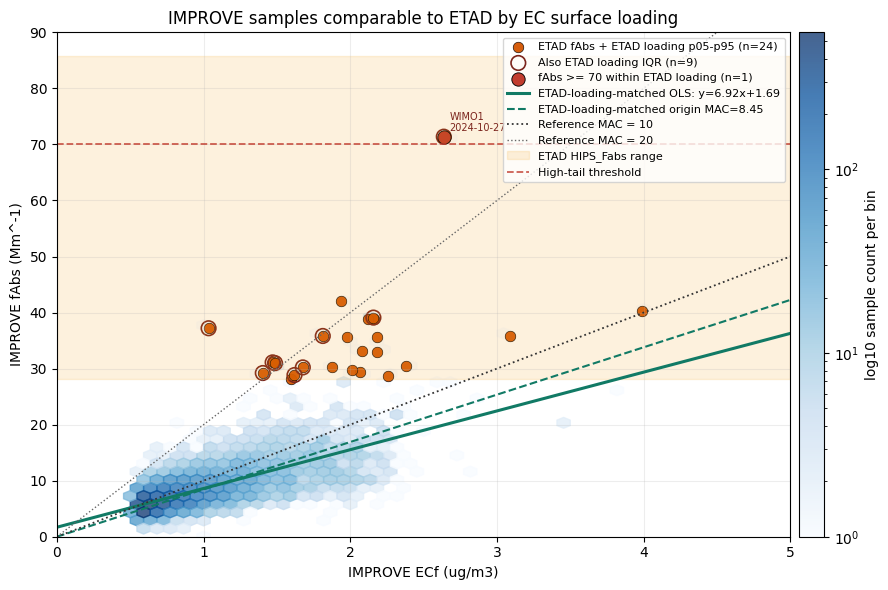

Main plot inclusion counts
- RT + valid loading + ETAD p05-p95 EC surface loading: 6,946
- Also in ETAD fAbs range: 24
- Also in ETAD loading IQR: 9
- fAbs >= 70 inside ETAD loading envelope: 1


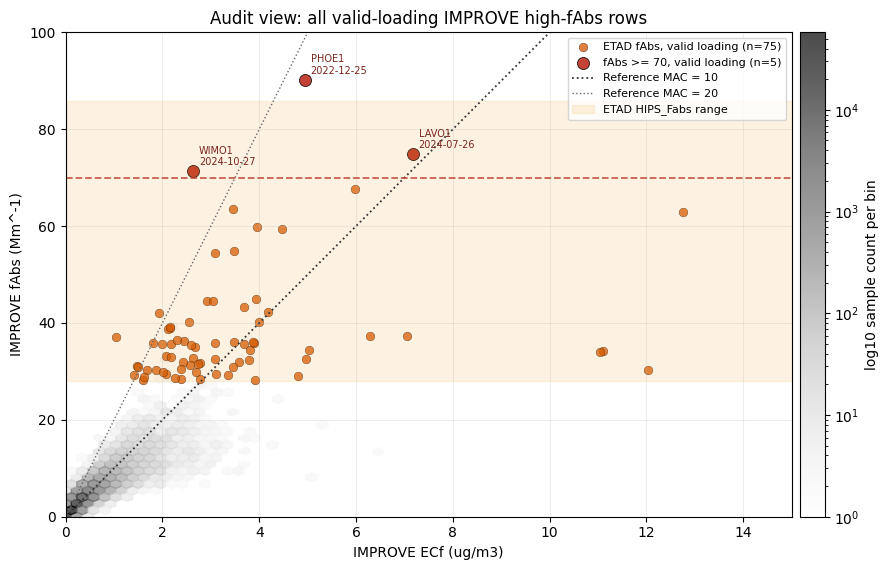

Broader audit: ETAD-fAbs points with lowest fAbs/EC ratios.


,SiteCode,SiteName,State,Date,ECf_Val,fAbs_Val,fAbs_per_EC,OCf_Val,OC_EC,FlowRate_Val,SampDur_Val,EC_loading_ug_cm2_primary,rt_available
358261,SYCA2,Sycamore Canyon,AZ,2023-10-21,43.76045,32.52,0.743137,151.94553,3.472211,19.9600,646.75,161.402668,True
352352,SNPA1,Snoqualmie Pass,WA,2020-09-12,38.53500,32.97,0.855586,58.08300,1.507279,18.8850,1440.00,299.410344,True
255696,CRLA1,Crater Lake NP,OR,2020-09-12,25.21560,28.30,1.122321,38.73800,1.536271,20.0400,1440.00,207.903342,True
289707,KALM1,Kalmiopsis,OR,2020-09-12,33.02900,38.91,1.178056,55.80690,1.689633,19.1700,1440.00,260.502554,True
241383,BRIG1,Brigantine NWR,NJ,2023-06-08,19.83952,45.64,2.300459,35.30347,1.779452,18.8425,811.50,86.674264,True
284873,ISLE1,Isle Royale NP,MI,2020-12-20,12.03570,30.28,2.515849,33.07370,2.747966,18.7700,1440.00,92.945865,True
377924,YOSE1,Yosemite NP,CA,2018-08-06,11.04040,34.01,3.080504,71.85650,6.508505,18.0975,1440.00,82.204926,True
270564,GICL1,Gila Wilderness,NM,2023-08-07,11.11148,34.31,3.087797,29.58710,2.662751,19.5125,1009.25,62.519506,True
315406,NOGA1,Nogales,AZ,2017-12-24,12.74510,62.93,4.937584,24.83370,1.948490,19.9075,1440.00,104.388924,True
324519,PENO1,Penobscot,ME,2025-05-31,7.04929,37.41,5.306917,23.64528,3.354278,20.6725,1042.25,43.395254,True


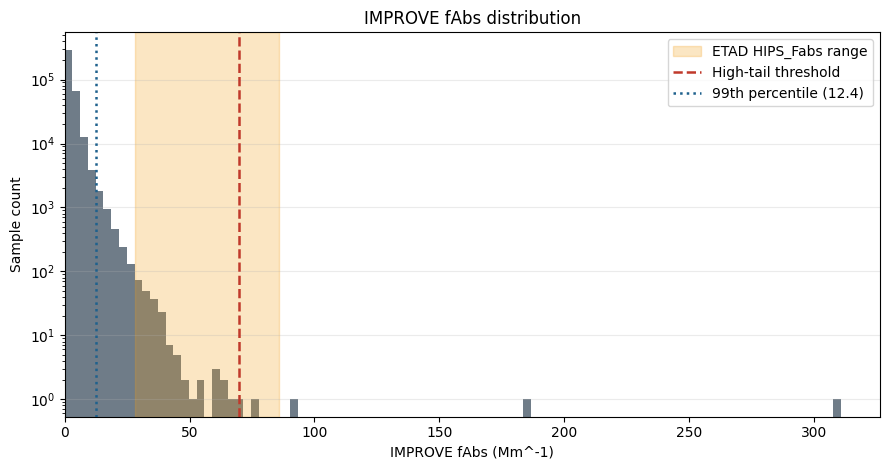

In [11]:
\
def label_points(ax, df, x_col='ECf_Val', y_col='fAbs_Val'):
    for _, row in df.iterrows():
        label = f"{row['SiteCode']}\n{pd.to_datetime(row['Date']).strftime('%Y-%m-%d')}"
        ax.annotate(label, (row[x_col], row[y_col]), xytext=(4, 4), textcoords='offset points', fontsize=7, color='#7B241C')


def add_mac_reference(ax, x_limit):
    x_line = np.linspace(0, x_limit, 200)
    ax.plot(x_line, 10 * x_line, color='0.20', lw=1.3, ls=':', label='Reference MAC = 10')
    ax.plot(x_line, 20 * x_line, color='0.40', lw=1.0, ls=':', label='Reference MAC = 20')


# Main comparison plot: ETAD-comparable filter loading only.
base_comparable = valid[
    valid['rt_available']
    & valid['EC_loading_ug'].notna()
    & valid['EC_loading_ug_cm2_primary'].between(ETAD_EC_LOADING_CM2_P05, ETAD_EC_LOADING_CM2_P95, inclusive='both')
    & (valid['ECf_Val'] > 0)
    & (valid['fAbs_Val'] > 0)
].copy()

etad_comparable = base_comparable[
    base_comparable['fAbs_Val'].between(ETAD_FABS_MIN, ETAD_FABS_MAX, inclusive='both')
].copy()
high_comparable = base_comparable[base_comparable['fAbs_Val'] >= HIGH_TAIL_THRESHOLD].copy()
iqr_etad_comparable = etad_comparable[
    etad_comparable['EC_loading_ug_cm2_primary'].between(ETAD_EC_LOADING_CM2_P25, ETAD_EC_LOADING_CM2_P75, inclusive='both')
].copy()

base_comparable.to_csv(OUT_DIR / 'improve_etad_loading_comparable_rows.csv', index=False)
etad_comparable.to_csv(OUT_DIR / 'improve_etad_fabs_and_loading_comparable_rows.csv', index=False)

fig, ax = plt.subplots(figsize=(9.5, 6.0))
plot_bg = base_comparable[(base_comparable['ECf_Val'] <= 5.0) & (base_comparable['fAbs_Val'] <= 90.0)].copy()
hb = ax.hexbin(
    plot_bg['ECf_Val'],
    plot_bg['fAbs_Val'],
    gridsize=55,
    extent=(0, 5, 0, 90),
    mincnt=1,
    bins='log',
    cmap='Blues',
    alpha=0.75,
)
cbar = fig.colorbar(hb, ax=ax, pad=0.01)
cbar.set_label('log10 sample count per bin')

ax.scatter(
    etad_comparable['ECf_Val'],
    etad_comparable['fAbs_Val'],
    s=58,
    color='#D35400',
    alpha=0.95,
    edgecolor='black',
    linewidth=0.45,
    label=f'ETAD fAbs + ETAD loading p05-p95 (n={len(etad_comparable)})',
)
if len(iqr_etad_comparable):
    ax.scatter(
        iqr_etad_comparable['ECf_Val'],
        iqr_etad_comparable['fAbs_Val'],
        s=110,
        facecolor='none',
        edgecolor='#7B241C',
        linewidth=1.2,
        label=f'Also ETAD loading IQR (n={len(iqr_etad_comparable)})',
    )
if len(high_comparable):
    ax.scatter(
        high_comparable['ECf_Val'],
        high_comparable['fAbs_Val'],
        s=92,
        color='#C0392B',
        alpha=0.98,
        edgecolor='black',
        linewidth=0.65,
        label=f'fAbs >= {HIGH_TAIL_THRESHOLD:g} within ETAD loading (n={len(high_comparable)})',
    )
    label_points(ax, high_comparable)

loading_fit = fit_fabs_ec(base_comparable)
x_line = np.linspace(0, 5, 200)
ax.plot(
    x_line,
    loading_fit['slope'] * x_line + loading_fit['intercept'],
    color='#117A65',
    lw=2.2,
    label=f"ETAD-loading-matched OLS: y={loading_fit['slope']:.2f}x+{loading_fit['intercept']:.2f}",
)
ax.plot(
    x_line,
    loading_fit['origin_mac'] * x_line,
    color='#117A65',
    lw=1.5,
    ls='--',
    label=f"ETAD-loading-matched origin MAC={loading_fit['origin_mac']:.2f}",
)
add_mac_reference(ax, 5)

ax.axhspan(ETAD_FABS_MIN, ETAD_FABS_MAX, color='#F39C12', alpha=0.14, label='ETAD HIPS_Fabs range')
ax.axhline(HIGH_TAIL_THRESHOLD, color='#C0392B', ls='--', lw=1.3, alpha=0.8, label='High-tail threshold')
ax.set_xlim(0, 5)
ax.set_ylim(0, 90)
ax.set_xlabel('IMPROVE ECf (ug/m3)')
ax.set_ylabel('IMPROVE fAbs (Mm^-1)')
ax.set_title('IMPROVE samples comparable to ETAD by EC surface loading')
ax.grid(alpha=0.22)
ax.legend(loc='upper right', fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(OUT_DIR / 'improve_fabs_ec_etad_comparable.png', dpi=240, bbox_inches='tight')
fig.savefig(OUT_DIR / 'improve_fabs_ec_scatter.png', dpi=240, bbox_inches='tight')
plt.show()

print('Main plot inclusion counts')
print(f'- RT + valid loading + ETAD p05-p95 EC surface loading: {len(base_comparable):,}')
print(f'- Also in ETAD fAbs range: {len(etad_comparable):,}')
print(f'- Also in ETAD loading IQR: {len(iqr_etad_comparable):,}')
print(f'- fAbs >= {HIGH_TAIL_THRESHOLD:g} inside ETAD loading envelope: {len(high_comparable):,}')

# Keep a separate audit plot for the whole valid-loading high-fAbs tail, not for the main paper comparison.
audit = valid[
    valid['rt_available']
    & valid['EC_loading_ug'].notna()
    & (valid['ECf_Val'] > 0)
    & (valid['fAbs_Val'] > 0)
].copy()
fig, ax = plt.subplots(figsize=(9.5, 5.8))
audit_bg = audit[(audit['ECf_Val'] <= 15) & (audit['fAbs_Val'] <= 100)].copy()
hb = ax.hexbin(
    audit_bg['ECf_Val'],
    audit_bg['fAbs_Val'],
    gridsize=65,
    extent=(0, 15, 0, 100),
    mincnt=1,
    bins='log',
    cmap='Greys',
    alpha=0.70,
)
cbar = fig.colorbar(hb, ax=ax, pad=0.01)
cbar.set_label('log10 sample count per bin')
audit_etad = audit[audit['fAbs_Val'].between(ETAD_FABS_MIN, ETAD_FABS_MAX, inclusive='both')].copy()
audit_high = audit[audit['fAbs_Val'] >= HIGH_TAIL_THRESHOLD].copy()
ax.scatter(audit_etad['ECf_Val'], audit_etad['fAbs_Val'], s=40, color='#D35400', alpha=0.75, edgecolor='black', linewidth=0.25, label=f'ETAD fAbs, valid loading (n={len(audit_etad)})')
ax.scatter(audit_high['ECf_Val'], audit_high['fAbs_Val'], s=75, color='#C0392B', alpha=0.95, edgecolor='black', linewidth=0.55, label=f'fAbs >= {HIGH_TAIL_THRESHOLD:g}, valid loading (n={len(audit_high)})')
label_points(ax, audit_high[audit_high['fAbs_Val'] <= 100])
add_mac_reference(ax, 15)
ax.axhspan(ETAD_FABS_MIN, ETAD_FABS_MAX, color='#F39C12', alpha=0.12, label='ETAD HIPS_Fabs range')
ax.axhline(HIGH_TAIL_THRESHOLD, color='#C0392B', ls='--', lw=1.3, alpha=0.8)
ax.set_xlim(0, 15)
ax.set_ylim(0, 100)
ax.set_xlabel('IMPROVE ECf (ug/m3)')
ax.set_ylabel('IMPROVE fAbs (Mm^-1)')
ax.set_title('Audit view: all valid-loading IMPROVE high-fAbs rows')
ax.grid(alpha=0.22)
ax.legend(loc='upper right', fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(OUT_DIR / 'improve_fabs_ec_valid_loading_audit.png', dpi=240, bbox_inches='tight')
plt.show()

# Table of points that look visually surprising in the broader valid-loading audit view.
surprising = audit_etad.sort_values('fAbs_per_EC').head(25).copy()
surprising_cols = [c for c in [
    'SiteCode', 'SiteName', 'State', 'Date', 'ECf_Val', 'fAbs_Val', 'fAbs_per_EC',
    'OCf_Val', 'OC_EC', 'FlowRate_Val', 'SampDur_Val', 'EC_loading_ug_cm2_primary', 'rt_available'
] if c in surprising.columns]
surprising[surprising_cols].to_csv(OUT_DIR / 'improve_etad_like_low_fabs_per_ec_points.csv', index=False)
print('Broader audit: ETAD-fAbs points with lowest fAbs/EC ratios.')
display(surprising[surprising_cols].head(15))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(valid['fAbs_Val'], bins=100, color='#566573', alpha=0.85)
ax.axvspan(ETAD_FABS_MIN, ETAD_FABS_MAX, color='#F39C12', alpha=0.25, label='ETAD HIPS_Fabs range')
ax.axvline(HIGH_TAIL_THRESHOLD, color='#C0392B', ls='--', lw=1.8, label='High-tail threshold')
ax.axvline(q99, color='#1F618D', ls=':', lw=1.8, label=f'99th percentile ({q99:.1f})')
ax.set_xlabel('IMPROVE fAbs (Mm^-1)')
ax.set_ylabel('Sample count')
ax.set_title('IMPROVE fAbs distribution')
ax.set_xlim(left=0)
ax.set_yscale('log')
ax.grid(alpha=0.25, axis='y')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'improve_fabs_distribution.png', dpi=220, bbox_inches='tight')
plt.show()


,dataset,n_for_plot,median,p25,p75,p90,p99
0,"IMPROVE ETAD-like, area 2.2",77,35.767508,29.217279,49.926215,111.989936,429.291583
1,"IMPROVE ETAD-like, area 3.5",77,22.482434,18.365147,31.382192,70.393674,269.840424
2,"IMPROVE ETAD-like, area 4",77,19.672130,16.069503,27.459418,61.594465,236.110371
7,SPARTAN ETAD,190,9.491196,6.763349,13.489698,17.552119,21.598146
8,SPARTAN INDH,63,4.617626,2.325924,7.211272,11.642714,32.206580
6,SPARTAN CHTS,163,2.400346,1.383315,3.609273,5.051096,8.633100
3,"IMPROVE all, area 2.2",30000,1.454004,0.708464,2.897602,5.188169,18.039086
9,SPARTAN USPA,130,0.996929,0.750916,1.229899,1.466366,2.025978
4,"IMPROVE all, area 3.5",30000,0.913945,0.445320,1.821350,3.261135,11.338854
5,"IMPROVE all, area 4",30000,0.799702,0.389655,1.593681,2.853493,9.921497


/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_48878/200141934.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=order, showfliers=False, patch_artist=True)


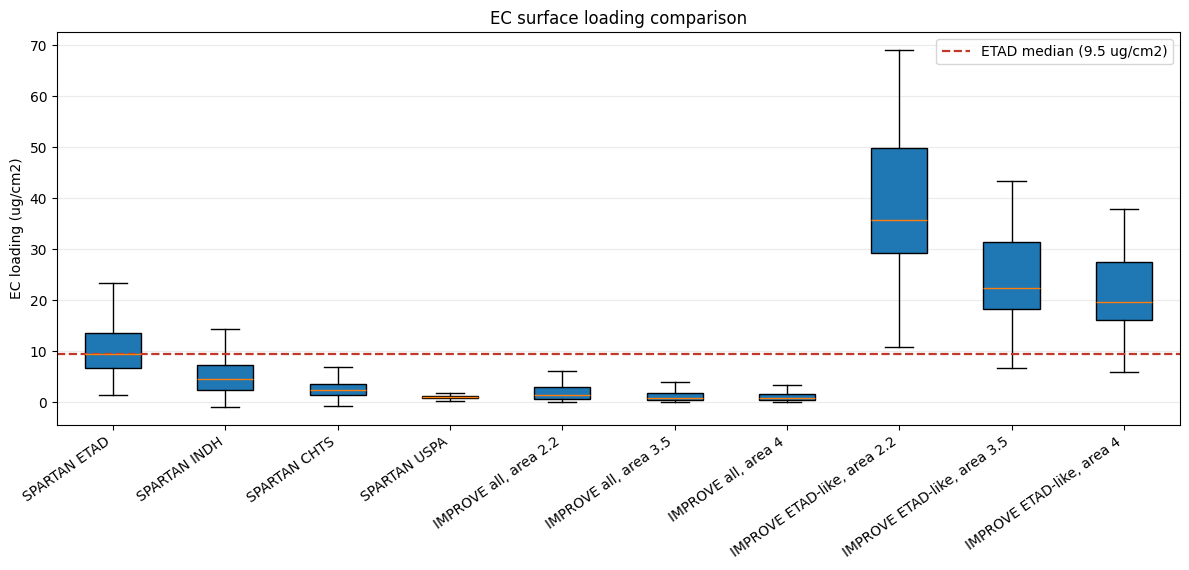

In [12]:
# Loading comparison using EC mass on filter. IMPROVE area sensitivity uses 2.2, 3.5, and 4.0 cm2; SPARTAN uses measured local areas.
plot_rows = []

def append_plot_values(label, values, sample_cap=30_000):
    s = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) > sample_cap:
        s = s.sample(n=sample_cap, random_state=RANDOM_SEED)
    plot_rows.extend({'dataset': label, 'loading_ug_cm2': float(v)} for v in s)

for site, g in spartan_wide.dropna(subset=['EC_loading_ug_cm2']).groupby('Site'):
    append_plot_values(f'SPARTAN {site}', g['EC_loading_ug_cm2'], sample_cap=100_000)

for area in IMPROVE_AREA_SENSITIVITY_CM2:
    col = f'EC_loading_ug_cm2_area_{safe_area(area)}'
    append_plot_values(f'IMPROVE all, area {area:g}', valid[col])
    append_plot_values(f'IMPROVE ETAD-like, area {area:g}', groups['ETAD_like'][col], sample_cap=100_000)

loading_plot_df = pd.DataFrame(plot_rows)
loading_plot_df.to_csv(OUT_DIR / 'loading_plot_values.csv', index=False)

loading_summary_rows = []
for label, g in loading_plot_df.groupby('dataset'):
    s = g['loading_ug_cm2'].dropna()
    loading_summary_rows.append({
        'dataset': label,
        'n_for_plot': len(s),
        'median': s.median(),
        'p25': s.quantile(0.25),
        'p75': s.quantile(0.75),
        'p90': s.quantile(0.90),
        'p99': s.quantile(0.99),
    })
loading_summary = pd.DataFrame(loading_summary_rows).sort_values('median', ascending=False)
loading_summary.to_csv(OUT_DIR / 'loading_summary_by_dataset.csv', index=False)
display(loading_summary)

order = [
    'SPARTAN ETAD', 'SPARTAN INDH', 'SPARTAN CHTS', 'SPARTAN USPA',
    'IMPROVE all, area 2.2', 'IMPROVE all, area 3.5', 'IMPROVE all, area 4',
    'IMPROVE ETAD-like, area 2.2', 'IMPROVE ETAD-like, area 3.5', 'IMPROVE ETAD-like, area 4',
]
order = [x for x in order if x in loading_plot_df['dataset'].unique()]

fig, ax = plt.subplots(figsize=(12, 5.8))
box_data = [loading_plot_df.loc[loading_plot_df['dataset'].eq(label), 'loading_ug_cm2'].dropna().values for label in order]
ax.boxplot(box_data, labels=order, showfliers=False, patch_artist=True)
ax.axhline(ETAD_EC_LOADING_CM2_MEDIAN, color='#C0392B', lw=1.6, ls='--', label=f'ETAD median ({ETAD_EC_LOADING_CM2_MEDIAN:.1f} ug/cm2)')
ax.set_ylabel('EC loading (ug/cm2)')
ax.set_title('EC surface loading comparison')
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.xticks(rotation=35, ha='right')
fig.tight_layout()
fig.savefig(OUT_DIR / 'ec_surface_loading_comparison.png', dpi=220, bbox_inches='tight')
plt.show()


## Full-Pull Interpretation

This is the decision logic for the April 14 fork. Two cautions matter:

1. A group selected directly on `fAbs` will naturally compress the `fAbs` axis, so slope/intercept inside the ETAD-like band should be treated as descriptive rather than definitive proof.
2. The strict `fAbs >= 70` group is the cleanest high-tail test, but it may be sparse even in the full FED pull.


In [13]:
\
def compact_fit_text(row):
    if row is None or row.empty or not np.isfinite(row.iloc[0]['slope']):
        return 'not enough data'
    r = row.iloc[0]
    ci = ''
    if {'slope_ci_low', 'slope_ci_high', 'intercept_ci_low', 'intercept_ci_high'}.issubset(row.columns) and np.isfinite(r.get('slope_ci_low', np.nan)):
        ci = f"; slope CI [{r['slope_ci_low']:.2f}, {r['slope_ci_high']:.2f}], intercept CI [{r['intercept_ci_low']:.2f}, {r['intercept_ci_high']:.2f}]"
    return f"n={int(r['n'])}, slope={r['slope']:.2f}, intercept={r['intercept']:.2f}, R2={r['r2']:.2f}, origin MAC={r['origin_mac']:.2f}, within-site slope={r.get('within_site_slope', np.nan):.2f}{ci}"

all_fit = fit_summary[fit_summary['group'].eq('all_valid')]
etad_fit = fit_summary[fit_summary['group'].eq('ETAD_like')]
high_fit = fit_summary[fit_summary['group'].eq('high_tail_ge70')]
top01_fit = fit_summary[fit_summary['group'].eq('top_0p1pct_fAbs')]
load_iqr_fit = fit_summary[fit_summary['group'].eq('loading_ETAD_IQR_area_3p5')]
load_p05p95_fit = fit_summary[fit_summary['group'].eq('loading_ETAD_p05p95_area_3p5')]

print('Current IMPROVE pull status')
print(f'- Valid EC + fAbs rows: {len(valid):,}')
print(f'- Date range: {valid["Date"].min().date()} to {valid["Date"].max().date()}')
print(f'- ETAD-like rows ({ETAD_FABS_MIN:.2f}-{ETAD_FABS_MAX:.2f} Mm^-1): {len(groups["ETAD_like"])}')
print(f'- High-tail rows (fAbs >= {HIGH_TAIL_THRESHOLD:.0f} Mm^-1): {len(groups["high_tail_ge70"])}')
print(f'- Above ETAD max rows (fAbs > {ETAD_FABS_MAX:.2f} Mm^-1): {len(groups["above_ETAD_max"])}')
print(f'- RT joined for ETAD-like rows: {groups["ETAD_like"]["rt_available"].sum():,}')
print('\nFits')
print(f'- all_valid: {compact_fit_text(all_fit)}')
print(f'- ETAD_like: {compact_fit_text(etad_fit)}')
print(f'- high_tail_ge70: {compact_fit_text(high_fit)}')
print(f'- top_0p1pct_fAbs: {compact_fit_text(top01_fit)}')
print(f'- loading_ETAD_IQR_area_3p5: {compact_fit_text(load_iqr_fit)}')
print(f'- loading_ETAD_p05p95_area_3p5: {compact_fit_text(load_p05p95_fit)}')

if len(groups['high_tail_ge70']) < 10:
    conclusion = (
        'The full local FED pull finds real IMPROVE samples in the ETAD fAbs range, but the strict high-tail group is still too small for a decisive slope/intercept test. '
        'ETAD-like IMPROVE samples are mostly an uncommon high-fAbs tail, and their fAbs-vs-EC fit is weak/compressed, but this is partly expected because the group is selected on fAbs itself. '
        'Treat this as supporting evidence that ETAD sits in a rare HIPS regime, not as a final proof of the Addis/SPARTAN mechanism.'
    )
elif len(groups['ETAD_like']) < 30:
    conclusion = (
        'Fork weakly constrained: ETAD-like IMPROVE samples are sparse. Interpret slope/intercept as descriptive only until broader or raw HIPS data are added.'
    )
else:
    high = high_fit.iloc[0]
    if np.isfinite(high['intercept']) and high['intercept'] > 10 and high['r2'] < 0.5:
        conclusion = (
            'Preliminary support for a high-loading HIPS/MAC-regime issue: strict high-fAbs IMPROVE samples also show a large positive intercept and weak/compressed EC relationship.'
        )
    elif np.isfinite(high['intercept']) and high['intercept'] <= 10 and high['r2'] >= 0.5:
        conclusion = (
            'Preliminary evidence against a generic high-fAbs IMPROVE behavior: strict high-fAbs IMPROVE samples have a relatively normal EC relationship, pointing back toward Addis/SPARTAN-specific behavior.'
        )
    else:
        conclusion = (
            'Mixed result: high-fAbs IMPROVE samples do not cleanly resolve the fork. Prioritize raw HIPS diagnostics and per-sample loading/flag review for these specific samples.'
        )

print('\nInterpretation')
print(conclusion)

summary_note = pd.DataFrame([{
    'valid_rows': len(valid),
    'date_min': valid['Date'].min(),
    'date_max': valid['Date'].max(),
    'etad_like_rows': len(groups['ETAD_like']),
    'high_tail_rows': len(groups['high_tail_ge70']),
    'above_etad_max_rows': len(groups['above_ETAD_max']),
    'rt_joined_rows': int(valid['rt_available'].sum()),
    'loading_available_rows': int(valid['EC_loading_ug'].notna().sum()),
    'etad_like_loading_available_rows': int(groups['ETAD_like']['EC_loading_ug'].notna().sum()),
    'conclusion': conclusion,
}])
summary_note.to_csv(OUT_DIR / 'current_pull_interpretation.csv', index=False)


Current IMPROVE pull status
- Valid EC + fAbs rows: 379,697
- Date range: 2003-01-03 to 2025-07-30
- ETAD-like rows (28.09-85.85 Mm^-1): 207
- High-tail rows (fAbs >= 70 Mm^-1): 5
- Above ETAD max rows (fAbs > 85.85 Mm^-1): 3
- RT joined for ETAD-like rows: 78

Fits
- all_valid: n=379697, slope=5.37, intercept=1.14, R2=0.57, origin MAC=6.70, within-site slope=4.18; slope CI [3.40, 6.53], intercept CI [0.90, 1.52]
- ETAD_like: n=207, slope=0.14, intercept=34.44, R2=0.01, origin MAC=3.60, within-site slope=0.40; slope CI [-0.01, 0.71], intercept CI [32.32, 35.59]
- high_tail_ge70: n=5, slope=19.77, intercept=24.05, R2=0.23, origin MAC=23.21, within-site slope=nan; slope CI [-53.02, 62.02], intercept CI [-195.84, 676.22]
- top_0p1pct_fAbs: n=380, slope=0.41, intercept=30.53, R2=0.01, origin MAC=3.81, within-site slope=1.03; slope CI [0.14, 1.06], intercept CI [28.61, 31.92]
- loading_ETAD_IQR_area_3p5: n=2989, slope=8.02, intercept=0.72, R2=0.27, origin MAC=8.66, within-site slope=7.74; s

## Files Written

The notebook writes reusable outputs to `research/ftir_hips_chem/output/improve_high_fabs_comparison/`:

- `loaded_file_manifest.csv`
- `fed_*` metadata CSVs, including dataset history, sites, parameters, and flag dictionaries when present
- `spartan_site_loading_summary.csv`
- `improve_valid_cleaned.csv`
- `improve_group_counts.csv`
- `improve_fabs_ec_fit_summary.csv`
- `improve_fabs_decile_fit_summary.csv`
- `improve_group_context_summary.csv`
- `improve_group_site_counts.csv`, `improve_group_month_counts.csv`, `improve_group_date_counts.csv`
- `improve_etad_like_samples.csv`
- `improve_high_tail_samples.csv`
- `improve_top_fabs_samples.csv`
- `current_pull_interpretation.csv`
- `improve_fabs_ec_scatter.png`
- `improve_fabs_distribution.png`
- `ec_surface_loading_comparison.png`
